In [11]:
%pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
fashion_sales = pd.read_csv("fashion_sales.csv")

fashion_sales.head()

,order_id,user_id,order_date,order_status,total_amount,name,email,gender,city,signup_date,...,product_name,category,brand,price,product_rating,review_rating,review_text,order_month,price_range,product_type
0,O00000004,U008986,2025-10-04 20:35:22,cancelled,689.50,Kurt Howard,nancy40@example.org,Female,New Barbarafurt,2024-12-04,...,Nimbus When,Clothing,Nimbus,67.54,3.58,NaN,NaN,2025-10,Mid Range ($50-$200),Jeans
1,O00000006,U003449,2024-10-13 09:02:27,completed,2258.34,Mason Owens,wharris@example.org,Other,Danielfort,2025-05-17,...,Harbor Night,Clothing,Harbor,209.10,3.68,NaN,NaN,2024-10,Premium ($200-$500),Skirt
2,O00000009,U000610,2025-10-29 07:00:11,cancelled,229.02,Rachel Taylor,parkerrichard@example.org,Male,Howardmouth,2025-05-15,...,Astra Without,Clothing,Astra,114.51,2.87,NaN,NaN,2025-10,Mid Range ($50-$200),Dress
3,O00000011,U004470,2025-08-14 09:59:55,shipped,1016.61,Morgan Lopez,michael10@example.com,Other,South Peggy,2025-10-14,...,Orion Most,Clothing,Orion,151.39,3.99,NaN,NaN,2025-08,Mid Range ($50-$200),Jacket
4,O00000012,U009480,2025-08-27 09:57:49,cancelled,600.23,Gabrielle Serrano,rachelblackwell@example.net,Other,New Timothy,2025-01-31,...,Nimbus Sit,Clothing,Nimbus,37.65,4.54,NaN,NaN,2025-08,Budget ($0-$50),T-Shirt


In [14]:
print("Dataset Shape:", fashion_sales.shape)

Dataset Shape: (4605, 25)


In [15]:
fashion_sales.columns.tolist()

['order_id',
 'user_id',
 'order_date',
 'order_status',
 'total_amount',
 'name',
 'email',
 'gender',
 'city',
 'signup_date',
 'order_item_id',
 'product_id',
 'quantity',
 'item_price',
 'item_total',
 'product_name',
 'category',
 'brand',
 'price',
 'product_rating',
 'review_rating',
 'review_text',
 'order_month',
 'price_range',
 'product_type']

In [16]:
fashion_sales.isnull().sum()

order_id             0
user_id              0
order_date           0
order_status         0
total_amount         0
name                 0
email                0
gender               0
city                 0
signup_date          0
order_item_id        0
product_id           0
quantity             0
item_price           0
item_total           0
product_name         0
category             0
brand                0
price                0
product_rating       0
review_rating     2994
review_text       2994
order_month          0
price_range          0
product_type         0
dtype: int64

In [17]:
fashion_sales[
    [
        "brand",
        "product_type",
        "price_range",
        "quantity",
        "item_price",
        "product_rating",
        "review_rating",
        "item_total"
    ]
].head()

,brand,product_type,price_range,quantity,item_price,product_rating,review_rating,item_total
0,Nimbus,Jeans,Mid Range ($50-$200),2,67.54,3.58,NaN,135.08
1,Harbor,Skirt,Premium ($200-$500),3,209.10,3.68,NaN,627.30
2,Astra,Dress,Mid Range ($50-$200),2,114.51,2.87,NaN,229.02
3,Orion,Jacket,Mid Range ($50-$200),1,151.39,3.99,NaN,151.39
4,Nimbus,T-Shirt,Budget ($0-$50),2,37.65,4.54,NaN,75.30


### Feature Selection

The relevant product and transaction features are examined to identify variables that may be useful for machine learning and recommendation analysis. Important characteristics include brand, product type, price range, quantity, product price, product rating, review rating, and total purchase value.

# supervised learning : 

# Statement qs :  “Can we predict a product's expected rating based on its brand, product type, and price characteristics?”

### Personalized Fashion Shopping Assistant:  Predicting product rating can support the assistant in recommending products that are likely to be better received.

### Numeric, complete, and relevant to product recommendations

Product rating prediction can support the Personalized Fashion Shopping Assistant by identifying products that may be better received by customers. The target variable is product_rating, while product characteristics are used as input features.

### Define Input Features and Target Variable

For supervised learning, the dataset is divided into input features (X) and a target variable (y). The input features include product brand, product type, price range, and item price. The target variable is product rating. The machine learning models will learn the relationship between these input features and product ratings.

In [18]:
# Input features (information used to make predictions)

X = fashion_sales[
    [
        "brand",
        "product_type",
        "price_range",
        "item_price"
    ]
]

# Target (what we want to predict)

y = fashion_sales["product_rating"]

In [19]:
X.head()

,brand,product_type,price_range,item_price
0,Nimbus,Jeans,Mid Range ($50-$200),67.54
1,Harbor,Skirt,Premium ($200-$500),209.10
2,Astra,Dress,Mid Range ($50-$200),114.51
3,Orion,Jacket,Mid Range ($50-$200),151.39
4,Nimbus,T-Shirt,Budget ($0-$50),37.65


In [20]:
y.head()

0    3.58
1    3.68
2    2.87
3    3.99
4    4.54
Name: product_rating, dtype: float64

In [21]:
X_encoded = pd.get_dummies(
    X,
    columns=["brand", "product_type", "price_range"],
    drop_first=True
)

X_encoded.head()

,item_price,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,brand_Pulse,brand_Solace,...,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit,price_range_Mid Range ($50-$200),price_range_Premium ($200-$500)
0,67.54,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,209.10,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,114.51,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,151.39,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
4,37.65,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [22]:
rating_check = fashion_sales.groupby(
    ["brand", "product_type", "price_range", "item_price"]
)["product_rating"].nunique()

print(rating_check.value_counts())

product_rating
1    1740
Name: count, dtype: int64


### Product-Level Data Investigation

### The number of unique products is examined because the dataset contains multiple transaction records for the same products. This step is important for understanding the true number of independent product observations available for product-level machine learning analysis.


Every unique combination of brand + product_type + price_range + item_price has exactly one unique product_rating.

And you have only 1,740 unique feature combinations but 4,605 rows, so many products appear repeatedly in the dataset.

In [23]:
# Check how many unique products you have
print("Total rows:", len(fashion_sales))
print("Unique products:", fashion_sales["product_id"].nunique())

Total rows: 4605
Unique products: 213


### The dataset contains 4,605 transaction records but only 213 unique products. Each product has one fixed product rating, meaning that multiple rows represent repeated transactions for the same products rather than independent product-rating observations.

In [24]:
fashion_sales.groupby("product_id")["product_rating"].nunique().value_counts()

product_rating
1    213
Name: count, dtype: int64

In [25]:
fashion_sales.head()

,order_id,user_id,order_date,order_status,total_amount,name,email,gender,city,signup_date,...,product_name,category,brand,price,product_rating,review_rating,review_text,order_month,price_range,product_type
0,O00000004,U008986,2025-10-04 20:35:22,cancelled,689.50,Kurt Howard,nancy40@example.org,Female,New Barbarafurt,2024-12-04,...,Nimbus When,Clothing,Nimbus,67.54,3.58,NaN,NaN,2025-10,Mid Range ($50-$200),Jeans
1,O00000006,U003449,2024-10-13 09:02:27,completed,2258.34,Mason Owens,wharris@example.org,Other,Danielfort,2025-05-17,...,Harbor Night,Clothing,Harbor,209.10,3.68,NaN,NaN,2024-10,Premium ($200-$500),Skirt
2,O00000009,U000610,2025-10-29 07:00:11,cancelled,229.02,Rachel Taylor,parkerrichard@example.org,Male,Howardmouth,2025-05-15,...,Astra Without,Clothing,Astra,114.51,2.87,NaN,NaN,2025-10,Mid Range ($50-$200),Dress
3,O00000011,U004470,2025-08-14 09:59:55,shipped,1016.61,Morgan Lopez,michael10@example.com,Other,South Peggy,2025-10-14,...,Orion Most,Clothing,Orion,151.39,3.99,NaN,NaN,2025-08,Mid Range ($50-$200),Jacket
4,O00000012,U009480,2025-08-27 09:57:49,cancelled,600.23,Gabrielle Serrano,rachelblackwell@example.net,Other,New Timothy,2025-01-31,...,Nimbus Sit,Clothing,Nimbus,37.65,4.54,NaN,NaN,2025-08,Budget ($0-$50),T-Shirt


In [26]:
# Select input features
X = fashion_sales[
    [
        "item_price",
        "brand",
        "product_type",
        "price_range"
    ]
]

# Target variable
y = fashion_sales["product_rating"]

In [27]:
X.head()

,item_price,brand,product_type,price_range
0,67.54,Nimbus,Jeans,Mid Range ($50-$200)
1,209.10,Harbor,Skirt,Premium ($200-$500)
2,114.51,Astra,Dress,Mid Range ($50-$200)
3,151.39,Orion,Jacket,Mid Range ($50-$200)
4,37.65,Nimbus,T-Shirt,Budget ($0-$50)


In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny name:")
print(y.name)

X shape: (4605, 4)
y shape: (4605,)

X columns:
['item_price', 'brand', 'product_type', 'price_range']

y name:
product_rating


### STEP 2 — Encode categorical variables

In [33]:
X_encoded = pd.get_dummies(
    X,
    columns=["brand", "product_type", "price_range"],
    drop_first=True,
    dtype=int
)

print("Encoded X shape:", X_encoded.shape)

X_encoded.head()

Encoded X shape: (4605, 23)


,item_price,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,brand_Pulse,brand_Solace,...,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit,price_range_Mid Range ($50-$200),price_range_Premium ($200-$500)
0,67.54,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,209.10,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,114.51,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,151.39,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
4,37.65,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### STEP 3 — Make encoded features your final X

In [34]:
X = X_encoded.copy()

print("Final X shape:", X.shape)

X.head()

Final X shape: (4605, 23)


,item_price,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,brand_Pulse,brand_Solace,...,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit,price_range_Mid Range ($50-$200),price_range_Premium ($200-$500)
0,67.54,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,209.10,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,114.51,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,151.39,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
4,37.65,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### STEP 4 — Check data types and missing values

In [35]:
print("Data types:\n")
print(X.dtypes)

print("\nTotal missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Data types:

item_price                          float64
brand_Astra                           int64
brand_Everest                         int64
brand_GreenLeaf                       int64
brand_Harbor                          int64
brand_NeoTech                         int64
brand_Nimbus                          int64
brand_Orion                           int64
brand_Pulse                           int64
brand_Solace                          int64
brand_Willow                          int64
brand_Zenith                          int64
product_type_Hoodie                   int64
product_type_Jacket                   int64
product_type_Jeans                    int64
product_type_Shirt                    int64
product_type_Shorts                   int64
product_type_Skirt                    int64
product_type_Sweater                  int64
product_type_T-Shirt                  int64
product_type_Tracksuit                int64
price_range_Mid Range ($50-$200)      int64
price_range_Premium

# STEP 5 — Grouped Train/Test Split

### A grouped train-test split is used to prevent the same product from appearing in both the training and testing datasets. Since the dataset contains repeated transactions for individual products, using a normal random split could cause data leakage. Grouping by product_id ensures that each product appears only in either the training set or the testing set.

In [36]:
from sklearn.model_selection import GroupShuffleSplit

# Product IDs used only for grouping
groups = fashion_sales["product_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3649, 23)
X_test: (956, 23)
y_train: (3649,)
y_test: (956,)


### STEP 6 — Verify the grouped split

In [147]:
train_products = set(
    fashion_sales.iloc[train_idx]["product_id"]
)

test_products = set(
    fashion_sales.iloc[test_idx]["product_id"]
)

overlap = train_products.intersection(test_products)

print("Training products:", len(train_products))
print("Testing products:", len(test_products))
print("Products appearing in BOTH:", len(overlap))

if len(overlap) == 0:
    print("\n✅ PASS: No product overlap")
else:
    print("\n❌ FAIL: Product overlap detected")

Training products: 170
Testing products: 43
Products appearing in BOTH: 0

✅ PASS: No product overlap


### STEP 7 — Final split verification

In [148]:
print("=" * 60)
print("FINAL GROUPED SPLIT VERIFICATION")
print("=" * 60)

print("\n1. DATASET SHAPES")
print("Full X shape:     ", X.shape)
print("Training X shape: ", X_train.shape)
print("Testing X shape:  ", X_test.shape)

print("\nFull y shape:     ", y.shape)
print("Training y shape: ", y_train.shape)
print("Testing y shape:  ", y_test.shape)

print("\n2. ROW COUNT CHECK")
print("Train + Test:", len(X_train) + len(X_test))
print("Original:", len(X))

if len(X_train) + len(X_test) == len(X):
    print("✅ PASS: All rows accounted for")

print("\n3. PRODUCT GROUP CHECK")
print("Products in BOTH:", len(overlap))

if len(overlap) == 0:
    print("✅ PASS: No product overlap")

print("\n4. TRAIN / TEST PERCENTAGE")

train_percent = len(X_train) / len(X) * 100
test_percent = len(X_test) / len(X) * 100

print(f"Training percentage: {train_percent:.2f}%")
print(f"Testing percentage: {test_percent:.2f}%")

FINAL GROUPED SPLIT VERIFICATION

1. DATASET SHAPES
Full X shape:      (4605, 23)
Training X shape:  (3649, 23)
Testing X shape:   (956, 23)

Full y shape:      (4605,)
Training y shape:  (3649,)
Testing y shape:   (956,)

2. ROW COUNT CHECK
Train + Test: 4605
Original: 4605
✅ PASS: All rows accounted for

3. PRODUCT GROUP CHECK
Products in BOTH: 0
✅ PASS: No product overlap

4. TRAIN / TEST PERCENTAGE
Training percentage: 79.24%
Testing percentage: 20.76%


### The final verification confirms that all records are accounted for after splitting the dataset and that there is no product overlap between the training and testing datasets. The percentage of records assigned to each dataset is also examined.

# STEP 8 — Multicollinearity (VIF)

### Variance Inflation Factor (VIF) is used to identify multicollinearity among the input features. Multicollinearity occurs when independent variables are highly correlated with each other. High multicollinearity can affect the stability and interpretation of regression models.

You can add:

A lower VIF generally indicates lower multicollinearity, while higher VIF values may indicate that some features contain overlapping information.

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.astype(float)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
22,price_range_Premium ($200-$500),5.215152
0,item_price,3.782370
21,price_range_Mid Range ($50-$200),2.964731
19,product_type_T-Shirt,2.544709
15,product_type_Shirt,2.182412
14,product_type_Jeans,2.179879
3,brand_GreenLeaf,2.084743
7,brand_Orion,2.058367
2,brand_Everest,2.029434
4,brand_Harbor,1.975929


### STEP 9 — Correlation Heatmap

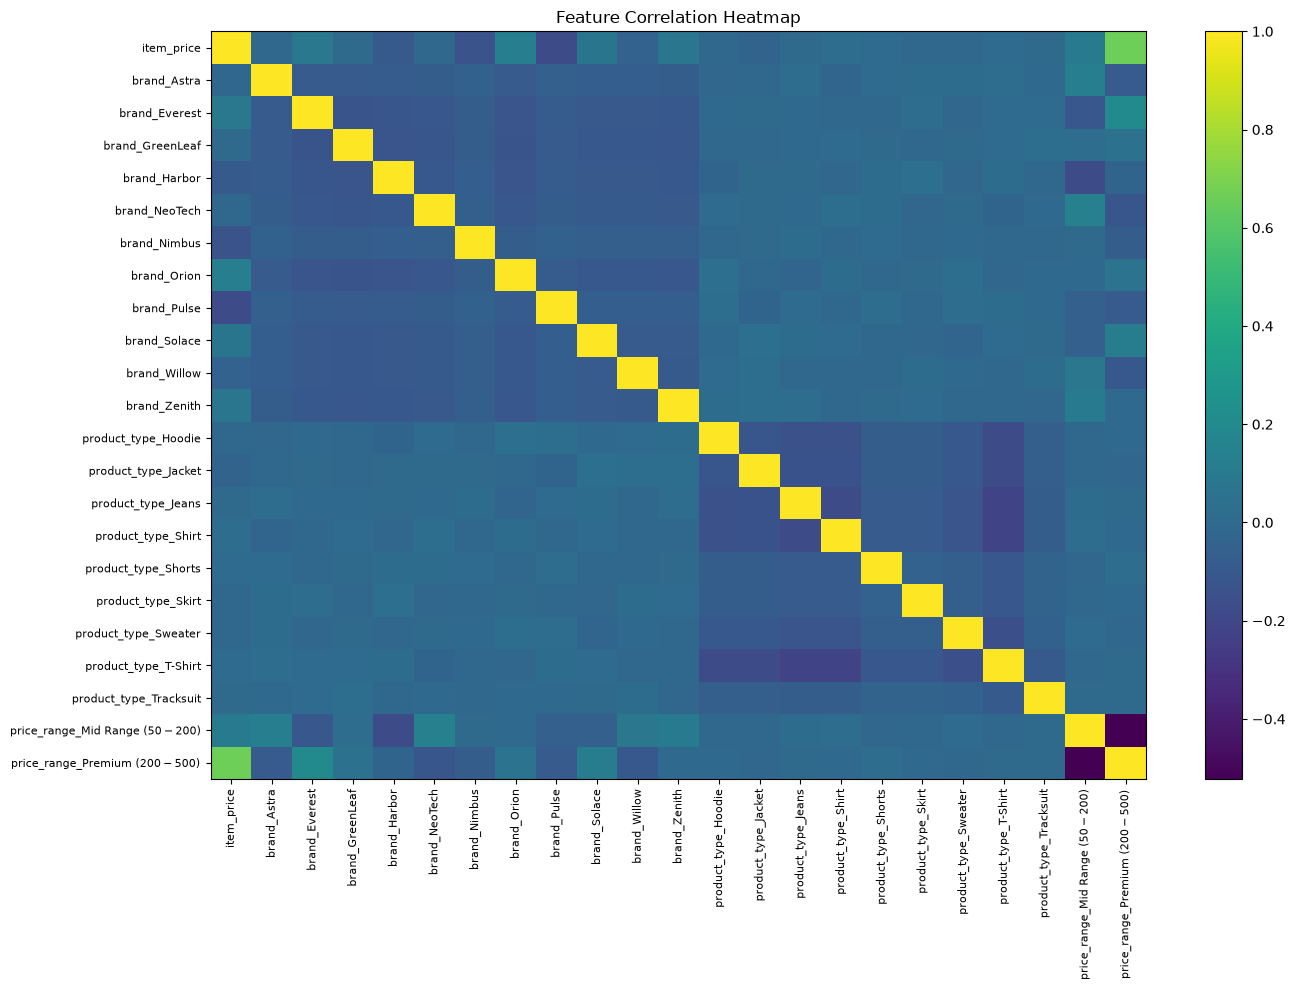

In [40]:
import matplotlib.pyplot as plt

corr_matrix = X_train.corr()

plt.figure(figsize=(14, 10))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    fontsize=8
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

A correlation heatmap is created to visualize relationships among the numerical and encoded input features. This analysis helps identify highly correlated variables and provides an additional check for potential multicollinearity.

### STEP 10 — Scaling

### Standardization is applied to the training and testing data using StandardScaler. Feature scaling ensures that numerical variables are measured on a similar scale. Scaling is particularly important for models such as Ridge Regression and Lasso Regression, which are sensitive to differences in feature magnitude.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (3649, 23)
X_test_scaled: (956, 23)


# Linear Regression
### Train and predict

In [42]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Train
linear_model.fit(X_train, y_train)

# Predictions
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

### Evaluation metrics

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_test_pred)

linear_mse = mean_squared_error(y_test, linear_test_pred)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_test_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 0.49861610458320527
MSE: 0.38243102155469355
RMSE: 0.6184100755604598
R² Score: 0.043714418245879516


In [44]:
# Adjusted R²
n = len(y_test)
p = X_test.shape[1]

linear_adjusted_r2 = 1 - (
    (1 - linear_r2) * (n - 1) / (n - p - 1)
)

print("Linear Adjusted R²:", linear_adjusted_r2)

Linear Adjusted R²: 0.02011509594937222


### Actual vs Predicted

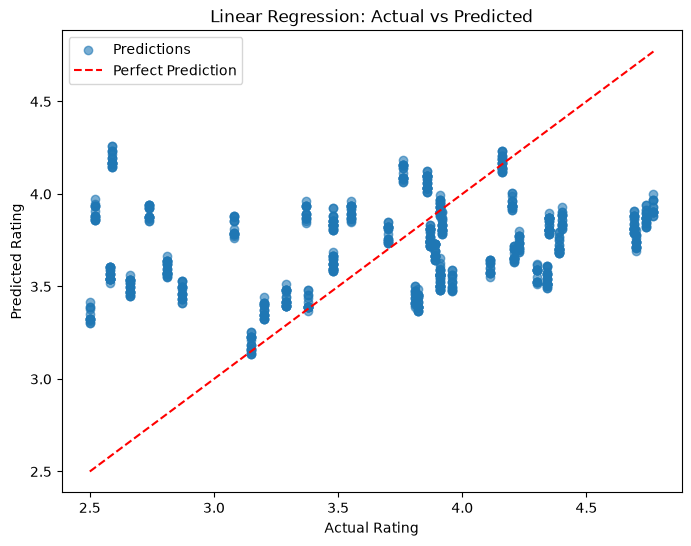

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_test_pred,
    alpha=0.6,
    label="Predictions"
)

# Perfect prediction line
min_value = min(y_test.min(), linear_test_pred.min())
max_value = max(y_test.max(), linear_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()

plt.show()

### Residual Plot

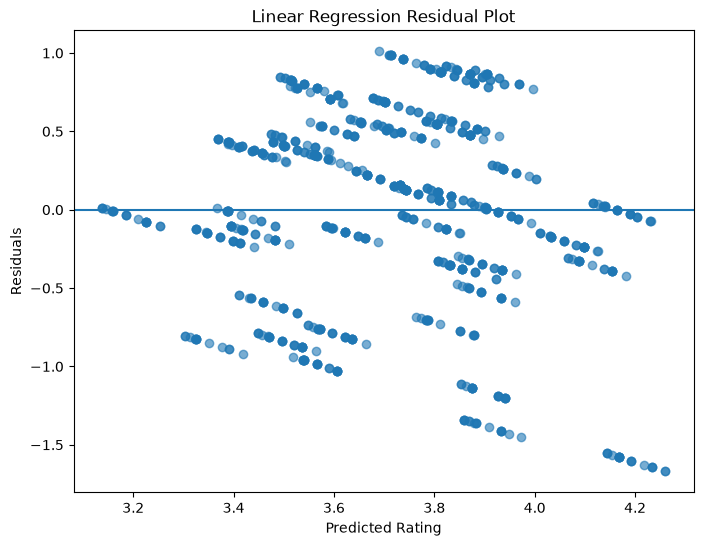

In [46]:
linear_residuals = y_test - linear_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    linear_test_pred,
    linear_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Linear Regression Residual Plot")

plt.show()

# Ridge Regression
### train and predict

In [48]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

### Evaluation metrics

In [49]:
ridge_mae = mean_absolute_error(y_test, ridge_test_pred)

ridge_mse = mean_squared_error(y_test, ridge_test_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_test_pred)

print("Ridge Regression Results")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression Results
MAE: 0.4985798258679681
MSE: 0.38241058493819974
RMSE: 0.618393551824564
R² Score: 0.04376552090385266


In [50]:
# Adjusted R²
ridge_adjusted_r2 = 1 - (
    (1 - ridge_r2) * (n - 1) / (n - p - 1)
)

print("Ridge Adjusted R²:", ridge_adjusted_r2)

Ridge Adjusted R²: 0.020167459724441228


### Actual vs Predicted

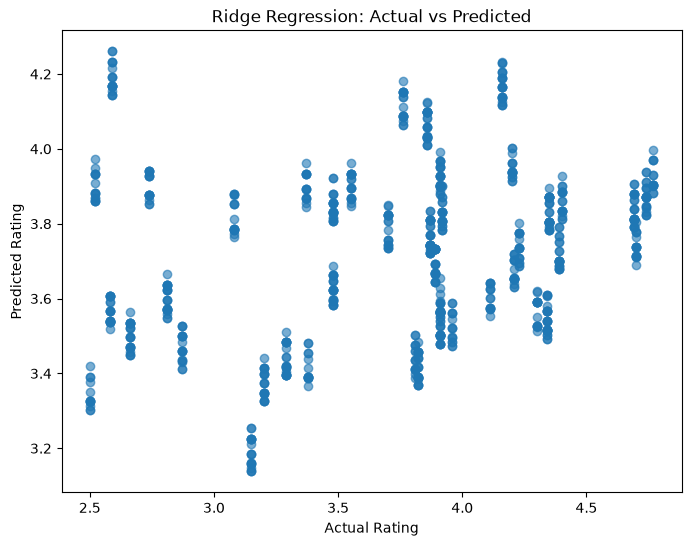

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, ridge_test_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

### Residual Plot

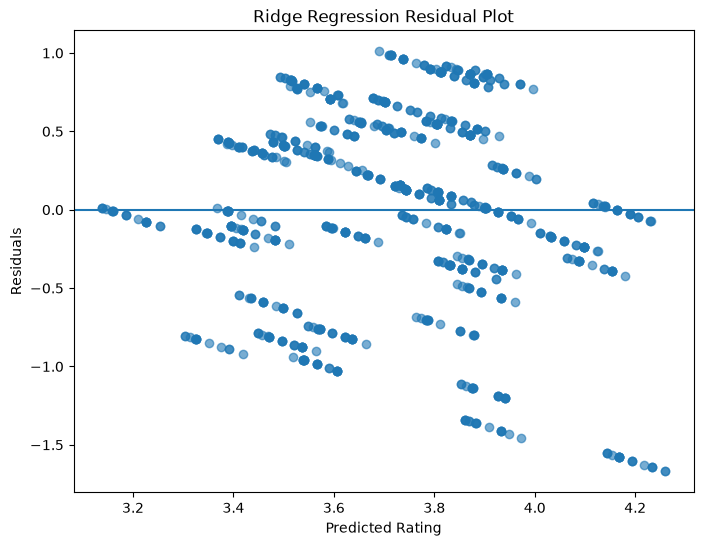

In [52]:
ridge_residuals = y_test - ridge_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    ridge_test_pred,
    ridge_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Ridge Regression Residual Plot")

plt.show()

# Lasso Regression
### Train and predict

In [53]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

### Evaluation

In [54]:
lasso_mae = mean_absolute_error(y_test, lasso_test_pred)

lasso_mse = mean_squared_error(y_test, lasso_test_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_test_pred)

print("Lasso Regression Results")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R² Score:", lasso_r2)

Lasso Regression Results
MAE: 0.49497713734825255
MSE: 0.37761170726900545
RMSE: 0.6145011857344178
R² Score: 0.055765325482979966


In [55]:
# Adjusted R²
lasso_adjusted_r2 = 1 - (
    (1 - lasso_r2) * (n - 1) / (n - p - 1)
)

print("Lasso Adjusted R²:", lasso_adjusted_r2)

Lasso Adjusted R²: 0.03246339682000632


### Actual vs Predicted

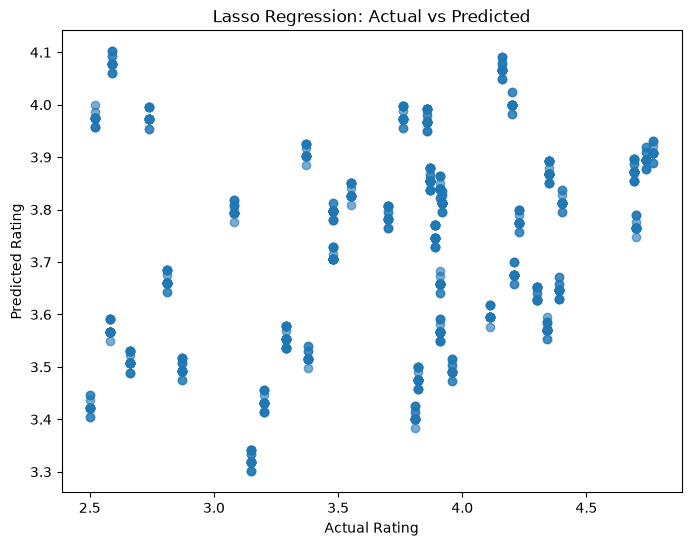

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lasso_test_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

### Residual Plot

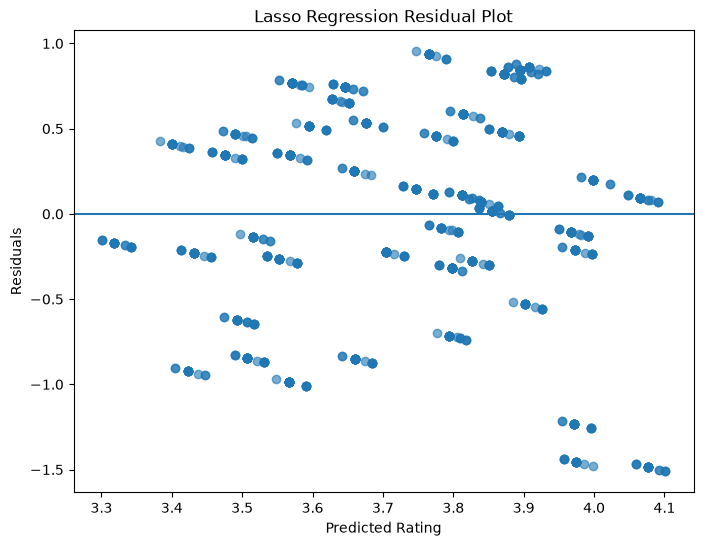

In [57]:
lasso_residuals = y_test - lasso_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    lasso_test_pred,
    lasso_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Lasso Regression Residual Plot")

plt.show()

# Decision Tree Regression
### Train and predict

In [58]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

### Evaluation

In [59]:
dt_mae = mean_absolute_error(y_test, dt_test_pred)

dt_mse = mean_squared_error(y_test, dt_test_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_test_pred)

print("Decision Tree Regression Results")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regression Results
MAE: 0.8278242677824271
MSE: 0.9915665271966531
RMSE: 0.9957743354780003
R² Score: -1.4794556923059496


In [60]:
# Adjusted R²
dt_adjusted_r2 = 1 - (
    (1 - dt_r2) * (n - 1) / (n - p - 1)
)

print("Decision Tree Adjusted R²:", dt_adjusted_r2)

Decision Tree Adjusted R²: -1.540643976558135


### Actual vs Predicted

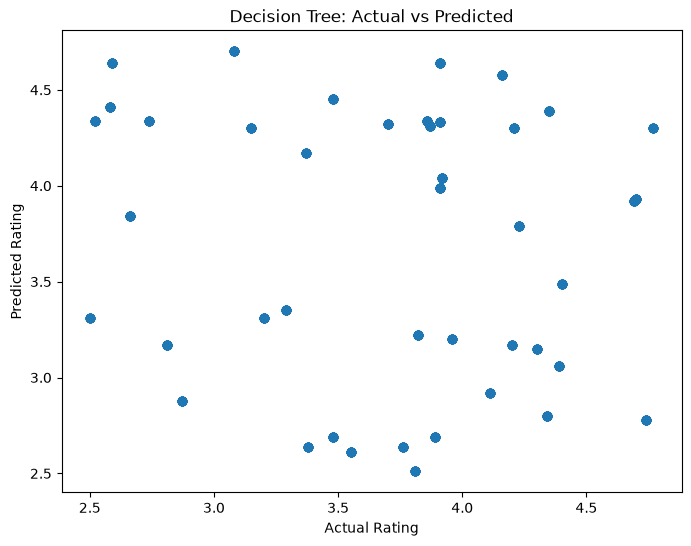

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, dt_test_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

### Residual Plot

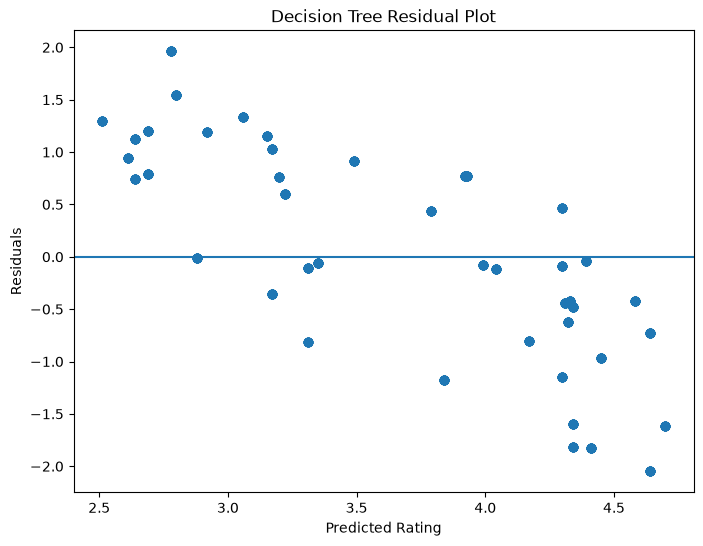

In [62]:
dt_residuals = y_test - dt_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    dt_test_pred,
    dt_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Decision Tree Residual Plot")

plt.show()

# Random Forest
### Train and predict

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

### Evaluation

In [64]:
rf_mae = mean_absolute_error(y_test, rf_test_pred)

rf_mse = mean_squared_error(y_test, rf_test_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Regression Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regression Results
MAE: 0.6822054393305432
MSE: 0.7057274649790787
RMSE: 0.8400758685851407
R² Score: -0.7647025512308265


In [65]:
# Adjusted R²
rf_adjusted_r2 = 1 - (
    (1 - rf_r2) * (n - 1) / (n - p - 1)
)

print("Random Forest Adjusted R²:", rf_adjusted_r2)

Random Forest Adjusted R²: -0.8082520777096989


### Actual vs Predicted

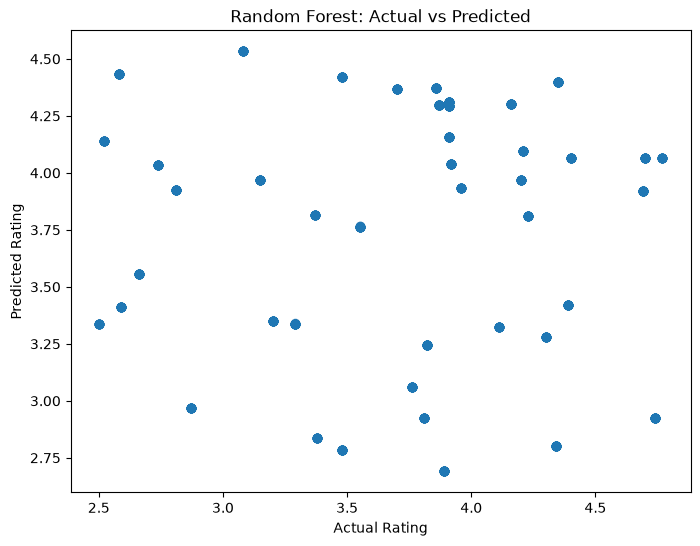

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_test_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

### Residual Plot

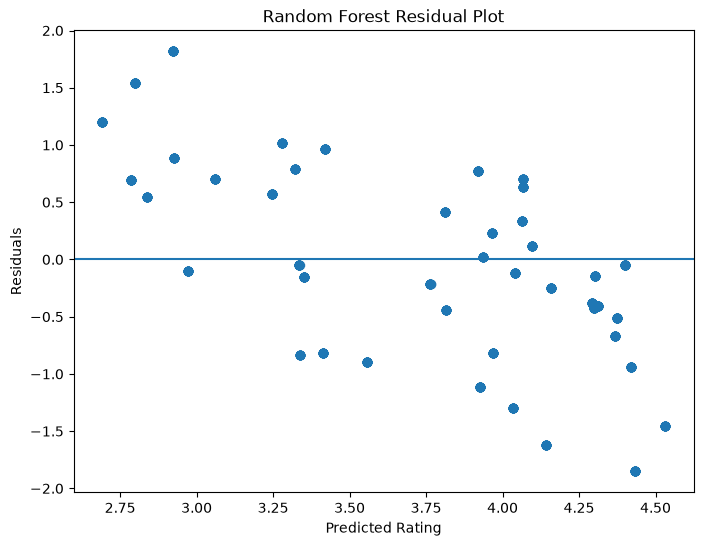

In [67]:
rf_residuals = y_test - rf_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_test_pred,
    rf_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot")

plt.show()

# Gradient Boosting
### Train and predict

In [68]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

### Evaluation

In [69]:
gb_mae = mean_absolute_error(y_test, gb_test_pred)

gb_mse = mean_squared_error(y_test, gb_test_pred)

gb_rmse = np.sqrt(gb_mse)

gb_r2 = r2_score(y_test, gb_test_pred)

print("Gradient Boosting Regression Results")
print("MAE:", gb_mae)
print("MSE:", gb_mse)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

Gradient Boosting Regression Results
MAE: 0.5341183570188455
MSE: 0.4553857672931034
RMSE: 0.6748227673197633
R² Score: -0.13871213069505584


In [70]:
# Adjusted R²
gb_adjusted_r2 = 1 - (
    (1 - gb_r2) * (n - 1) / (n - p - 1)
)

print("Gradient Boosting Adjusted R²:", gb_adjusted_r2)

Gradient Boosting Adjusted R²: -0.16681339572293807


### Actual vs Predicted

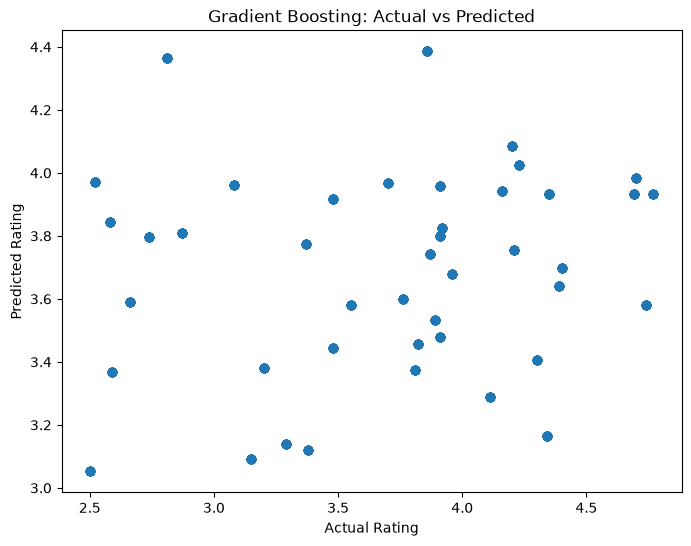

In [71]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_test_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

### Residual Plot

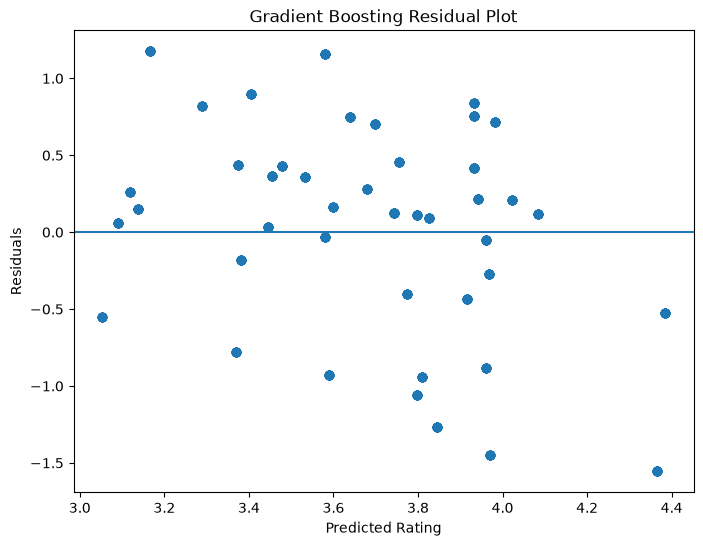

In [72]:
gb_residuals = y_test - gb_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    gb_test_pred,
    gb_residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.title("Gradient Boosting Residual Plot")

plt.show()

### STEP 11 — Final Model Comparison

### The performance of all six supervised learning models is compared using MAE, MSE, RMSE, R², and Adjusted R². The comparison allows the best-performing model to be selected based on prediction accuracy and explanatory performance.

In [73]:
# ==========================================
# STEP 11 — FINAL MODEL COMPARISON
# ==========================================

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    
    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse,
        dt_mse,
        rf_mse,
        gb_mse
    ],
    
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    
    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ],
    
    "Adjusted R²": [
        linear_adjusted_r2,
        ridge_adjusted_r2,
        lasso_adjusted_r2,
        dt_adjusted_r2,
        rf_adjusted_r2,
        gb_adjusted_r2
    ]
})

# Round the values
comparison_df = comparison_df.round(4)

comparison_df

,Model,MAE,MSE,RMSE,R²,Adjusted R²
0,Linear Regression,0.4986,0.3824,0.6184,0.0437,0.0201
1,Ridge Regression,0.4986,0.3824,0.6184,0.0438,0.0202
2,Lasso Regression,0.4950,0.3776,0.6145,0.0558,0.0325
3,Decision Tree,0.8278,0.9916,0.9958,-1.4795,-1.5406
4,Random Forest,0.6822,0.7057,0.8401,-0.7647,-0.8083
5,Gradient Boosting,0.5341,0.4554,0.6748,-0.1387,-0.1668


### STEP 12 — Identify the Best Models

In [74]:
# ==========================================
# STEP 12 — BEST MODEL BY EACH METRIC
# ==========================================

print("Best Model based on MAE:")
print(comparison_df.loc[comparison_df["MAE"].idxmin(), "Model"])

print("\nBest Model based on MSE:")
print(comparison_df.loc[comparison_df["MSE"].idxmin(), "Model"])

print("\nBest Model based on RMSE:")
print(comparison_df.loc[comparison_df["RMSE"].idxmin(), "Model"])

print("\nBest Model based on R²:")
print(comparison_df.loc[comparison_df["R²"].idxmax(), "Model"])

print("\nBest Model based on Adjusted R²:")
print(comparison_df.loc[comparison_df["Adjusted R²"].idxmax(), "Model"])

Best Model based on MAE:
Lasso Regression

Best Model based on MSE:
Lasso Regression

Best Model based on RMSE:
Lasso Regression

Best Model based on R²:
Lasso Regression

Best Model based on Adjusted R²:
Lasso Regression


### Among the six supervised machine learning models evaluated, Lasso Regression demonstrated the best overall performance, achieving the lowest MAE, MSE, and RMSE and the highest R² and Adjusted R² scores. Therefore, Lasso Regression was selected as the best-performing supervised model for the available dataset. However, the relatively low R² score indicates that the available product features have limited predictive power for accurately predicting product ratings.

### STEP 13 — Bias–Variance Analysis

### Bias-variance analysis is performed by comparing training and testing R² scores. A large difference between training and testing performance may indicate overfitting, while poor performance on both datasets may indicate underfitting.

In [75]:
linear_train_pred
linear_test_pred

ridge_train_pred
ridge_test_pred

lasso_train_pred
lasso_test_pred

dt_train_pred
dt_test_pred

rf_train_pred
rf_test_pred

gb_train_pred
gb_test_pred

array([3.80937741, 3.44545846, 3.13835705, 4.38534473, 3.45583891,
       3.44545846, 3.53215496, 3.77346576, 3.58968638, 3.58968638,
       3.91565994, 3.05205454, 4.08447266, 3.09031823, 3.74270922,
       3.94256166, 3.96881138, 3.63997194, 3.79877533, 3.95974788,
       3.58968638, 3.91565994, 3.80937741, 3.47942155, 3.58968638,
       3.37539828, 3.40474256, 3.82538741, 4.3657885 , 3.16537848,
       3.77346576, 3.47942155, 3.74270922, 4.02346541, 3.94256166,
       3.40474256, 3.9613255 , 3.75415713, 4.02346541, 3.74270922,
       3.36837039, 3.38056017, 3.98277224, 3.74270922, 3.44545846,
       3.93209956, 3.38056017, 3.63997194, 4.3657885 , 3.16537848,
       3.74270922, 3.47942155, 3.16537848, 3.77346576, 3.45583891,
       3.96881138, 3.95974788, 3.36837039, 3.58968638, 3.79877533,
       3.37539828, 3.97058342, 3.47942155, 3.36837039, 3.79796586,
       3.09031823, 3.44545846, 3.58968638, 3.11940203, 3.98277224,
       4.38534473, 3.13835705, 3.09031823, 3.96881138, 3.74270

In [76]:
# ==========================================
#  BIAS-VARIANCE ANALYSIS
# ==========================================

bias_variance_df = pd.DataFrame({
    
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Training R²": [
        r2_score(y_train, linear_train_pred),
        r2_score(y_train, ridge_train_pred),
        r2_score(y_train, lasso_train_pred),
        r2_score(y_train, dt_train_pred),
        r2_score(y_train, rf_train_pred),
        r2_score(y_train, gb_train_pred)
    ],
    
    "Testing R²": [
        r2_score(y_test, linear_test_pred),
        r2_score(y_test, ridge_test_pred),
        r2_score(y_test, lasso_test_pred),
        r2_score(y_test, dt_test_pred),
        r2_score(y_test, rf_test_pred),
        r2_score(y_test, gb_test_pred)
    ]
})

# Calculate R² Gap
bias_variance_df["R² Gap"] = (
    bias_variance_df["Training R²"] -
    bias_variance_df["Testing R²"]
)

bias_variance_df = bias_variance_df.round(4)

bias_variance_df

,Model,Training R²,Testing R²,R² Gap
0,Linear Regression,0.1463,0.0437,0.1026
1,Ridge Regression,0.1463,0.0438,0.1025
2,Lasso Regression,0.1297,0.0558,0.0740
3,Decision Tree,1.0000,-1.4795,2.4795
4,Random Forest,1.0000,-0.7647,1.7647
5,Gradient Boosting,0.6979,-0.1387,0.8366


### STEP 14 — Interpret the R² Gap

In [77]:
# ==========================================
#  MODEL FIT INTERPRETATION
# ==========================================

def interpret_model(row):
    
    train_r2 = row["Training R²"]
    test_r2 = row["Testing R²"]
    gap = row["R² Gap"]
    
    if train_r2 < 0.60 and test_r2 < 0.60:
        return "Underfitting"
    
    elif gap > 0.10:
        return "Overfitting"
    
    elif gap <= 0.10 and test_r2 >= 0.60:
        return "Good Fit"
    
    else:
        return "Needs Review"


bias_variance_df["Interpretation"] = bias_variance_df.apply(
    interpret_model,
    axis=1
)

bias_variance_df

,Model,Training R²,Testing R²,R² Gap,Interpretation
0,Linear Regression,0.1463,0.0437,0.1026,Underfitting
1,Ridge Regression,0.1463,0.0438,0.1025,Underfitting
2,Lasso Regression,0.1297,0.0558,0.0740,Underfitting
3,Decision Tree,1.0000,-1.4795,2.4795,Overfitting
4,Random Forest,1.0000,-0.7647,1.7647,Overfitting
5,Gradient Boosting,0.6979,-0.1387,0.8366,Overfitting


# XG boost 
### Train and Predict

In [141]:
%pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [143]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror"
)

# Train the model
xgb_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
xgb_train_pred = xgb_model.predict(X_train_scaled)

xgb_test_pred = xgb_model.predict(X_test_scaled)

### Evaluation

In [144]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_test_pred
)

xgb_rmse = np.sqrt(
    xgb_mse
)

xgb_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print("XGBoost Regression Results")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R² Score:", xgb_r2)

XGBoost Regression Results
MAE: 0.5083337992604308
MSE: 0.4003904553074749
RMSE: 0.6327641387653656
R² Score: -0.0011939353820096255


In [145]:
# Adjusted R²
n = len(y_test)
p = X_test.shape[1]

xgb_adjusted_r2 = 1 - (
    (1 - xgb_r2) * (n - 1) /
    (n - p - 1)
)

print("XGBoost Adjusted R²:", xgb_adjusted_r2)

XGBoost Adjusted R²: -0.025901511040578473


### XGBoost Regression was tested as an additional advanced ensemble model. However, the model produced a negative R² score, indicating that it did not improve prediction performance for this dataset. Therefore, XGBoost was not selected as the final supervised learning model.

# Product-Level Dataset Investigation

### Product-Level Dataset Analysis

Further analysis revealed that the dataset contains 4,605 transaction records but only 213 unique products. Since each product has one fixed product rating, the transaction-level records contain repeated product information. Therefore, a separate product-level dataset was created to represent each unique fashion product only once

In [79]:
print("Unique products:", fashion_sales["product_id"].nunique())

print("\nUnique brands:", fashion_sales["brand"].nunique())

print("\nUnique product types:", fashion_sales["product_type"].nunique())

print("\nUnique price ranges:", fashion_sales["price_range"].nunique())

print("\nProduct rating distribution:")
print(fashion_sales["product_rating"].describe())

Unique products: 213

Unique brands: 12

Unique product types: 10

Unique price ranges: 3

Product rating distribution:
count    4605.000000
mean        3.724215
std         0.663224
min         2.500000
25%         3.200000
50%         3.820000
75%         4.300000
max         4.880000
Name: product_rating, dtype: float64


In [80]:
print(
    fashion_sales[
        ["item_price", "product_rating"]
    ].corr()
)

                item_price  product_rating
item_price        1.000000       -0.072175
product_rating   -0.072175        1.000000


In [81]:
print(
    fashion_sales.groupby("brand")["product_rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

               mean  count
brand                     
Acme       4.098006    341
Pulse      4.045851    241
Everest    3.972990    485
Harbor     3.899353    603
GreenLeaf  3.823302    530
NeoTech    3.690320    375
Orion      3.628498    486
Solace     3.573035    346
Willow     3.508415    328
Zenith     3.391580    386
Nimbus     3.388383    167
Astra      3.355268    317


In [82]:
print(
    fashion_sales.groupby("product_type")["product_rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

                  mean  count
product_type                 
Tracksuit     3.822266    128
T-Shirt       3.754101    946
Skirt         3.745178    197
Shirt         3.741344    677
Sweater       3.722310    381
Jacket        3.720449    468
Jeans         3.708068    673
Dress         3.694480    433
Shorts        3.684039    203
Hoodie        3.679800    499


In [83]:
# Check whether product rating is constant for every product

product_rating_check = (
    fashion_sales
    .groupby("product_id")["product_rating"]
    .nunique()
)

print(product_rating_check.value_counts())

print(
    "\nProducts with more than one rating:",
    (product_rating_check > 1).sum()
)

product_rating
1    213
Name: count, dtype: int64

Products with more than one rating: 0


### it means every one of  213 products has exactly one product rating.

### So the 4,605 rows are repeated transaction records, not 4,605 independent product-rating observations.

4,605 transaction rows

        ↓
213 unique products

        ↓
213 unique product ratings


# Creating a product level dataset 

### A product-level dataset is created by removing duplicate product IDs. This results in one observation per unique product and provides a cleaner structure for product-based machine learning, clustering, and recommendation analysis.


In [84]:
# ==========================================
# CREATE PRODUCT-LEVEL DATASET
# ==========================================

product_data = (
    fashion_sales[
        [
            "product_id",
            "brand",
            "product_type",
            "price_range",
            "item_price",
            "product_rating"
        ]
    ]
    .drop_duplicates(subset="product_id")
    .reset_index(drop=True)
)

print("Product-level dataset shape:", product_data.shape)

product_data.head()

Product-level dataset shape: (213, 6)


,product_id,brand,product_type,price_range,item_price,product_rating
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54


### Verify the Product-Level Dataset

 The product-level dataset is verified by checking the total number of rows, number of unique products, duplicate product IDs, and missing values. This confirms that each product is represented only once.

In [85]:
print("Number of rows:", len(product_data))

print("Unique products:", product_data["product_id"].nunique())

print(
    "Duplicate product IDs:",
    product_data["product_id"].duplicated().sum()
)

print(
    "Missing values:",
    product_data.isnull().sum().sum()
)

Number of rows: 213
Unique products: 213
Duplicate product IDs: 0
Missing values: 0


### Verify the Target

In [86]:
print(product_data["product_rating"].describe())

count    213.000000
mean       3.717136
std        0.671911
min        2.500000
25%        3.170000
50%        3.810000
75%        4.300000
max        4.880000
Name: product_rating, dtype: float64


# 1. Create X and Y

In [88]:


X_product = product_data[
    [
        "item_price",
        "brand",
        "product_type",
        "price_range"
    ]
].copy()

y_product = product_data["product_rating"].copy()

print("X shape:", X_product.shape)
print("y shape:", y_product.shape)

X_product.head()

X shape: (213, 4)
y shape: (213,)


,item_price,brand,product_type,price_range
0,67.54,Nimbus,Jeans,Mid Range ($50-$200)
1,209.10,Harbor,Skirt,Premium ($200-$500)
2,114.51,Astra,Dress,Mid Range ($50-$200)
3,151.39,Orion,Jacket,Mid Range ($50-$200)
4,37.65,Nimbus,T-Shirt,Budget ($0-$50)


### 2.Encode Categorical Variables

In [91]:

X_product_encoded = pd.get_dummies(
    X_product,
    columns=["brand", "product_type", "price_range"],
    drop_first=True,
    dtype=int
)

print("Encoded X shape:", X_product_encoded.shape)

X_product_encoded.head()

Encoded X shape: (213, 23)


,item_price,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,brand_Pulse,brand_Solace,...,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit,price_range_Mid Range ($50-$200),price_range_Premium ($200-$500)
0,67.54,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,209.10,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,114.51,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,151.39,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
4,37.65,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### 3.Train/Test Split

In [92]:


from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_product_encoded,
    y_product,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train_p.shape)
print("X_test:", X_test_p.shape)

print("y_train:", y_train_p.shape)
print("y_test:", y_test_p.shape)

X_train: (170, 23)
X_test: (43, 23)
y_train: (170,)
y_test: (43,)


### 4.Scale the Features

In [93]:


from sklearn.preprocessing import StandardScaler

scaler_product = StandardScaler()

X_train_p_scaled = scaler_product.fit_transform(X_train_p)

X_test_p_scaled = scaler_product.transform(X_test_p)

print("Scaled training shape:", X_train_p_scaled.shape)
print("Scaled testing shape:", X_test_p_scaled.shape)

Scaled training shape: (170, 23)
Scaled testing shape: (43, 23)


### 5.new product-level variables.

In [98]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_p, y_train_p)

linear_train_pred = linear_model.predict(X_train_p)
linear_test_pred = linear_model.predict(X_test_p)

print("Training predictions:", len(linear_train_pred))
print("Testing predictions:", len(linear_test_pred))
print("Actual testing values:", len(y_test_p))

Training predictions: 170
Testing predictions: 43
Actual testing values: 43


# MODEL 1 — Linear Regression

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train
linear_product_model = LinearRegression()

linear_product_model.fit(
    X_train_p,
    y_train_p
)

# Predictions
linear_product_train_pred = linear_product_model.predict(X_train_p)
linear_product_test_pred = linear_product_model.predict(X_test_p)


### Evaluation

In [100]:
linear_mae = mean_absolute_error(y_test_p, linear_test_pred)

linear_mse = mean_squared_error(y_test_p, linear_test_pred)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test_p, linear_test_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 0.621126967382949
MSE: 0.5726418201907821
RMSE: 0.7567310091378456
R² Score: -0.16980022362976444


# AI Content-Based Recommendation System

### The Personalized Fashion Shopping Assistant uses a content-based recommendation approach. Products are compared based on their characteristics, including brand, product type, price, and product rating. The system identifies products with similar characteristics and recommends them to users.

In [103]:
print("Product dataset shape:", product_data.shape)

print("\nColumns:")
print(product_data.columns.tolist())

product_data.head()

Product dataset shape: (213, 6)

Columns:
['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating']


,product_id,brand,product_type,price_range,item_price,product_rating
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54


### Select Recommendation Features

In [104]:
recommendation_features = product_data[
    [
        "brand",
        "product_type",
        "item_price",
        "product_rating"
    ]
].copy()

recommendation_features.head()

,brand,product_type,item_price,product_rating
0,Nimbus,Jeans,67.54,3.58
1,Harbor,Skirt,209.10,3.68
2,Astra,Dress,114.51,2.87
3,Orion,Jacket,151.39,3.99
4,Nimbus,T-Shirt,37.65,4.54


### Encode Recommendation Features

In [105]:
recommendation_encoded = pd.get_dummies(
    recommendation_features,
    columns=["brand", "product_type"],
    dtype=int
)

print("Encoded shape:", recommendation_encoded.shape)

recommendation_encoded.head()

Encoded shape: (213, 24)


,item_price,product_rating,brand_Acme,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,...,product_type_Dress,product_type_Hoodie,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit
0,67.54,3.58,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,209.10,3.68,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,114.51,2.87,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,151.39,3.99,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,37.65,4.54,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


### Scale Recommendation Features

In [106]:
from sklearn.preprocessing import StandardScaler

scaler_recommendation = StandardScaler()

recommendation_scaled = scaler_recommendation.fit_transform(
    recommendation_encoded
)

print("Recommendation matrix shape:")
print(recommendation_scaled.shape)

Recommendation matrix shape:
(213, 24)


# Cosine Similarity
### Cosine similarity is used to calculate how similar each product is to every other product. Products with higher similarity scores have more similar characteristics and are considered stronger recommendation candidates.

In [107]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    recommendation_scaled
)

print("Similarity matrix shape:")
print(product_similarity.shape)

Similarity matrix shape:
(213, 213)


### Recommendation Function

In [116]:
def recommend_products(product_id, n_recommendations=5):

    # Find the selected product
    product_indices = product_data[
        product_data["product_id"] == product_id
    ].index

    # Check if product exists
    if len(product_indices) == 0:
        return "Product ID not found."

    product_index = product_indices[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(product_similarity[product_index])
    )

    # Sort from most similar to least similar
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected product itself
    similarity_scores = similarity_scores[1:]

    # Get top recommendation indices
    top_indices = [
        index
        for index, score in similarity_scores[:n_recommendations]
    ]

    # Return recommended products
    return product_data.iloc[top_indices][
        [
            "product_id",
            "brand",
            "product_type",
            "price_range",
            "item_price",
            "product_rating"
        ]
    ]

In [118]:
product_data = product_data.reset_index(drop=True)

print(product_data.index)

RangeIndex(start=0, stop=213, step=1)


In [119]:
product_data[
    [
        "product_id",
        "brand",
        "product_type",
        "item_price",
        "product_rating"
    ]
].head(10)

,product_id,brand,product_type,item_price,product_rating
0,P001247,Nimbus,Jeans,67.54,3.58
1,P001002,Harbor,Skirt,209.10,3.68
2,P001301,Astra,Dress,114.51,2.87
3,P000162,Orion,Jacket,151.39,3.99
4,P000022,Nimbus,T-Shirt,37.65,4.54
5,P001370,Harbor,T-Shirt,38.92,3.94
6,P000614,Solace,T-Shirt,135.38,3.30
7,P000494,Astra,Sweater,148.44,3.65
8,P001080,Acme,Dress,18.31,4.63
9,P000304,Willow,T-Shirt,120.82,2.68


### Example Recommendation

In [120]:
recommend_products(
    "P001247",
    n_recommendations=5
)

,product_id,brand,product_type,price_range,item_price,product_rating
211,P000511,Nimbus,Jeans,Budget ($0-$50),34.13,2.60
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54
38,P000466,Nimbus,Shirt,Mid Range ($50-$200),76.15,2.61
199,P001536,Nimbus,Jacket,Budget ($0-$50),37.11,3.92
124,P001910,Nimbus,Hoodie,Mid Range ($50-$200),76.19,3.13


# K - Means clustering 

### “Can we group fashion products into meaningful clusters based on their brand, product type, price range, item price, and product rating to identify similar product segments?”


### K-Means clustering was used to segment the 213 unique fashion products into six groups based on similarities in brand, product type, item price, and product rating. The resulting cluster labels were added to the product-level dataset to support product segmentation and improve the recommendation system by identifying products with similar characteristics.

In [121]:
product_data

,product_id,brand,product_type,price_range,item_price,product_rating
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54
...,...,...,...,...,...,...
208,P000774,Harbor,Sweater,Budget ($0-$50),20.40,4.69
209,P000119,Pulse,Dress,Premium ($200-$500),265.21,4.77
210,P001242,Astra,T-Shirt,Mid Range ($50-$200),99.47,3.84
211,P000511,Nimbus,Jeans,Budget ($0-$50),34.13,2.60


### Select Features for Clustering

Brand, product type, item price, and product rating are selected as features for K-Means clustering. These characteristics represent important differences and similarities between fashion products.

In [122]:
clustering_features = product_data[
    [
        "brand",
        "product_type",
        "item_price",
        "product_rating"
    ]
].copy()

clustering_features.head()

,brand,product_type,item_price,product_rating
0,Nimbus,Jeans,67.54,3.58
1,Harbor,Skirt,209.10,3.68
2,Astra,Dress,114.51,2.87
3,Orion,Jacket,151.39,3.99
4,Nimbus,T-Shirt,37.65,4.54


### Encode Categorical Variables

In [123]:
clustering_encoded = pd.get_dummies(
    clustering_features,
    columns=["brand", "product_type"],
    dtype=int
)

print("Encoded shape:", clustering_encoded.shape)

clustering_encoded.head()

Encoded shape: (213, 24)


,item_price,product_rating,brand_Acme,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,brand_Nimbus,brand_Orion,...,product_type_Dress,product_type_Hoodie,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit
0,67.54,3.58,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,209.10,3.68,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,114.51,2.87,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,151.39,3.99,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,37.65,4.54,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


### Scale the Features

In [124]:
from sklearn.preprocessing import StandardScaler

scaler_kmeans = StandardScaler()

clustering_scaled = scaler_kmeans.fit_transform(
    clustering_encoded
)

print("Scaled data shape:")
print(clustering_scaled.shape)

Scaled data shape:
(213, 24)


### Find the Best Number of Clusters (Elbow Method)

The Elbow Method is used to examine how clustering inertia changes as the number of clusters increases. The goal is to identify a point where increasing the number of clusters provides smaller improvements.

In [125]:
from sklearn.cluster import KMeans

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(clustering_scaled)

    inertia.append(kmeans.inertia_)

### Plot the Elbow Curve

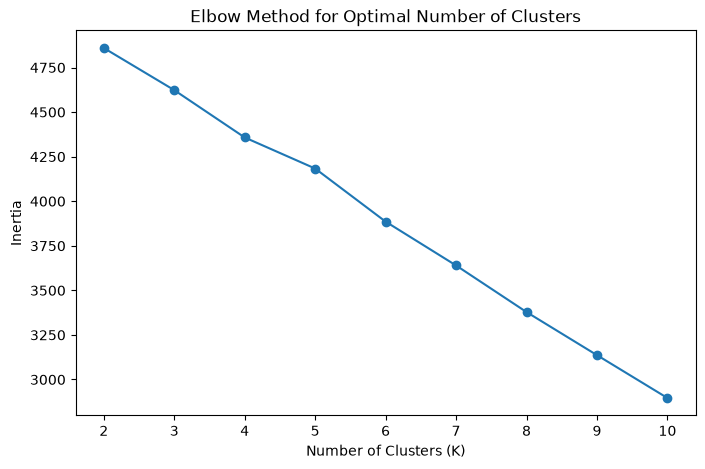

In [126]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(k_values)

plt.show()


# Calculate Silhouette Scores

### The Silhouette Score is calculated to evaluate how well-separated and internally consistent the clusters are. Higher silhouette scores generally indicate that products within the same cluster are more similar to each other and more distinct from products in other clusters.

In [127]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        clustering_scaled
    )

    score = silhouette_score(
        clustering_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

# Display results
silhouette_results = pd.DataFrame({
    "Number of Clusters (K)": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Number of Clusters (K),Silhouette Score
0,2,0.050278
1,3,0.057890
2,4,0.080581
3,5,0.093229
4,6,0.136171
5,7,0.166875
6,8,0.197351
7,9,0.223331
8,10,0.249377


### Plot the Silhouette Scores

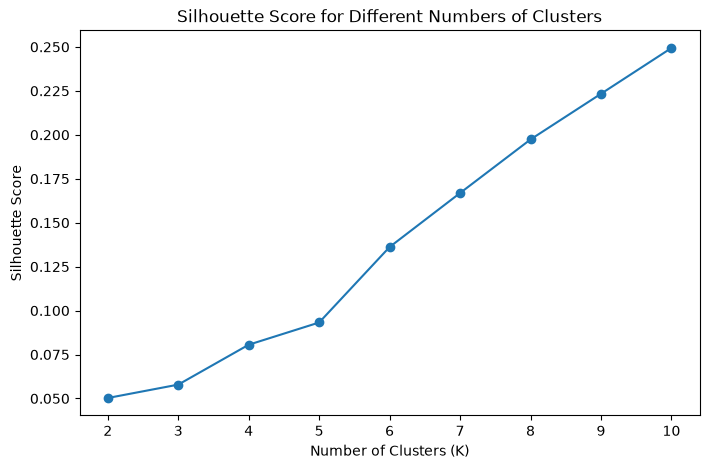

In [128]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score for Different Numbers of Clusters")

plt.xticks(k_values)

plt.show()

 ### silhouette score shows a noticeable improvement around K = 6, 
 ### and six clusters are still reasonably interpretable for only 213 products.

# Train K-Means with K = 6

In [129]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

product_data["cluster"] = kmeans_model.fit_predict(
    clustering_scaled
)

print("Cluster counts:")
print(product_data["cluster"].value_counts().sort_index())

product_data.head()

Cluster counts:
cluster
0    26
1    68
2    28
3    49
4    22
5    20
Name: count, dtype: int64


,product_id,brand,product_type,price_range,item_price,product_rating,cluster
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,4
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,1
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,2
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,1


### check the cluster profiles

In [130]:
cluster_summary = product_data.groupby("cluster").agg(
    products=("product_id", "count"),
    avg_price=("item_price", "mean"),
    avg_rating=("product_rating", "mean")
)

print(cluster_summary)

         products   avg_price  avg_rating
cluster                                  
0              26   84.529231    3.902692
1              68  114.387647    3.635294
2              28   99.470000    3.596786
3              49  134.682245    3.813673
4              22   97.166364    3.799091
5              20  106.452000    3.596000


###  Analyze Brand and Product Type in Each Cluster

In [131]:
# Brand distribution by cluster
cluster_brand = pd.crosstab(
    product_data["cluster"],
    product_data["brand"]
)

cluster_brand

brand,Acme,Astra,Everest,GreenLeaf,Harbor,NeoTech,Nimbus,Orion,Pulse,Solace,Willow,Zenith
cluster,,,,,,,,,,,,
0,1,0,3,2,4,1,1,4,2,3,4,1
1,4,0,7,10,12,6,1,4,4,4,6,10
2,2,12,1,1,3,2,1,4,1,1,0,0
3,3,1,5,7,6,6,2,8,2,4,4,1
4,3,2,3,2,2,1,2,1,1,2,0,3
5,2,1,3,2,0,0,2,1,2,1,2,4


In [132]:
# Product type distribution by cluster
cluster_product_type = pd.crosstab(
    product_data["cluster"],
    product_data["product_type"]
)

cluster_product_type

product_type,Dress,Hoodie,Jacket,Jeans,Shirt,Shorts,Skirt,Sweater,T-Shirt,Tracksuit
cluster,,,,,,,,,,
0,0,0,26,0,0,0,0,0,0,0
1,0,0,0,0,0,12,13,0,40,3
2,1,0,0,0,0,2,0,18,7,0
3,15,0,0,0,34,0,0,0,0,0
4,0,0,0,22,0,0,0,0,0,0
5,0,20,0,0,0,0,0,0,0,0


### Get Main Characteristics of Each Cluster

In [133]:
cluster_profile = product_data.groupby("cluster").agg(
    number_of_products=("product_id", "count"),
    average_price=("item_price", "mean"),
    average_rating=("product_rating", "mean")
)

print(cluster_profile)

         number_of_products  average_price  average_rating
cluster                                                   
0                        26      84.529231        3.902692
1                        68     114.387647        3.635294
2                        28      99.470000        3.596786
3                        49     134.682245        3.813673
4                        22      97.166364        3.799091
5                        20     106.452000        3.596000


In [134]:
cluster_modes = product_data.groupby("cluster").agg(
    most_common_brand=("brand", lambda x: x.mode()[0]),
    most_common_product_type=("product_type", lambda x: x.mode()[0])
)

cluster_modes

,most_common_brand,most_common_product_type
cluster,,
0,Harbor,Jacket
1,Harbor,T-Shirt
2,Astra,Sweater
3,Orion,Shirt
4,Acme,Jeans
5,Zenith,Hoodie


In [135]:
# joining 
final_cluster_profile = cluster_profile.join(cluster_modes)

final_cluster_profile

,number_of_products,average_price,average_rating,most_common_brand,most_common_product_type
cluster,,,,,
0,26,84.529231,3.902692,Harbor,Jacket
1,68,114.387647,3.635294,Harbor,T-Shirt
2,28,99.470000,3.596786,Astra,Sweater
3,49,134.682245,3.813673,Orion,Shirt
4,22,97.166364,3.799091,Acme,Jeans
5,20,106.452000,3.596000,Zenith,Hoodie


### Visualize Clusters: Price vs Rating

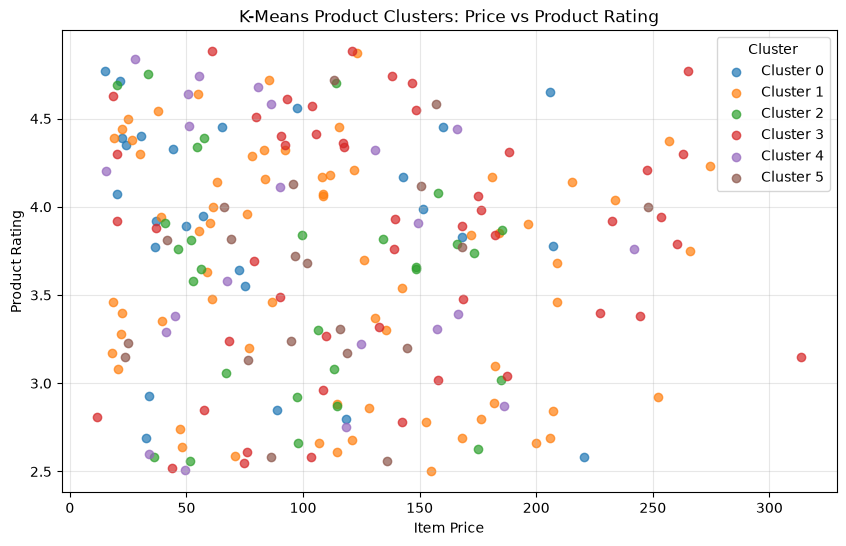

In [136]:
plt.figure(figsize=(10, 6))

for cluster in sorted(product_data["cluster"].unique()):

    cluster_data = product_data[
        product_data["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["item_price"],
        cluster_data["product_rating"],
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Item Price")
plt.ylabel("Product Rating")

plt.title("K-Means Product Clusters: Price vs Product Rating")

plt.legend(title="Cluster")

plt.grid(alpha=0.3)

plt.show()

### Check Products Inside Each Cluster

In [137]:
for cluster in sorted(product_data["cluster"].unique()):

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)

    display(
        product_data[
            product_data["cluster"] == cluster
        ][
            [
                "product_id",
                "brand",
                "product_type",
                "price_range",
                "item_price",
                "product_rating"
            ]
        ].head(10)
    )


CLUSTER 0


,product_id,brand,product_type,price_range,item_price,product_rating
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99
16,P000455,NeoTech,Jacket,Mid Range ($50-$200),65.06,4.45
24,P000542,Everest,Jacket,Budget ($0-$50),36.54,3.77
25,P000113,Harbor,Jacket,Budget ($0-$50),22.55,4.39
41,P000195,Willow,Jacket,Mid Range ($50-$200),72.69,3.64
42,P001787,Willow,Jacket,Mid Range ($50-$200),160.19,4.45
55,P000729,Orion,Jacket,Budget ($0-$50),49.66,3.89
78,P000173,Harbor,Jacket,Budget ($0-$50),30.32,4.40
83,P001772,Acme,Jacket,Budget ($0-$50),20.18,4.07
92,P000547,Everest,Jacket,Premium ($200-$500),207.26,3.78



CLUSTER 1


,product_id,brand,product_type,price_range,item_price,product_rating
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54
5,P001370,Harbor,T-Shirt,Budget ($0-$50),38.92,3.94
6,P000614,Solace,T-Shirt,Mid Range ($50-$200),135.38,3.30
9,P000304,Willow,T-Shirt,Mid Range ($50-$200),120.82,2.68
10,P000991,Everest,Skirt,Budget ($0-$50),19.08,4.39
13,P000748,Willow,T-Shirt,Mid Range ($50-$200),128.37,2.86
20,P001290,Solace,T-Shirt,Mid Range ($50-$200),108.57,4.07
23,P000826,Acme,T-Shirt,Budget ($0-$50),26.79,4.38
26,P000032,Orion,T-Shirt,Premium ($200-$500),265.99,3.75



CLUSTER 2


...

,product_id,brand,product_type,price_range,item_price,product_rating
8,P001080,Acme,Dress,Budget ($0-$50),18.31,4.63
12,P001639,Everest,Shirt,Premium ($200-$500),253.60,3.94
15,P001601,GreenLeaf,Shirt,Mid Range ($50-$200),93.07,4.61
18,P000864,NeoTech,Shirt,Mid Range ($50-$200),168.44,3.48
22,P000059,Orion,Dress,Mid Range ($50-$200),176.48,3.98
31,P000123,Solace,Shirt,Premium ($200-$500),244.44,3.38
38,P000466,Nimbus,Shirt,Mid Range ($50-$200),76.15,2.61
40,P001026,Harbor,Shirt,Mid Range ($50-$200),168.25,3.89
45,P000870,Orion,Dress,Mid Range ($50-$200),132.71,3.32
51,P000726,NeoTech,Shirt,Mid Range ($50-$200),109.92,3.27



CLUSTER 4


,product_id,brand,product_type,price_range,item_price,product_rating
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58
17,P001871,GreenLeaf,Jeans,Mid Range ($50-$200),118.36,2.75
21,P001430,Astra,Jeans,Budget ($0-$50),41.44,3.29
34,P000808,Astra,Jeans,Mid Range ($50-$200),125.02,3.22
36,P001733,Zenith,Jeans,Mid Range ($50-$200),166.64,3.39
52,P001619,Everest,Jeans,Budget ($0-$50),15.52,4.20
54,P001212,Harbor,Jeans,Budget ($0-$50),49.21,2.51
66,P001547,Orion,Jeans,Mid Range ($50-$200),149.44,3.91
76,P000821,Acme,Jeans,Mid Range ($50-$200),166.22,4.44
79,P001624,Pulse,Jeans,Mid Range ($50-$200),50.81,4.64



CLUSTER 5


,product_id,brand,product_type,price_range,item_price,product_rating
19,P000775,Everest,Hoodie,Mid Range ($50-$200),69.10,3.82
33,P000562,Willow,Hoodie,Budget ($0-$50),23.79,3.15
39,P000942,Acme,Hoodie,Mid Range ($50-$200),157.00,4.58
69,P000776,Pulse,Hoodie,Budget ($0-$50),41.51,3.81
110,P000668,Nimbus,Hoodie,Mid Range ($50-$200),168.02,3.77
116,P001366,Pulse,Hoodie,Mid Range ($50-$200),95.81,4.13
117,P001647,Acme,Hoodie,Mid Range ($50-$200),118.80,3.17
121,P000941,Solace,Hoodie,Budget ($0-$50),25.10,3.23
124,P001910,Nimbus,Hoodie,Mid Range ($50-$200),76.19,3.13
128,P000217,Zenith,Hoodie,Mid Range ($50-$200),101.57,3.68


### Add Cluster Information to Your Recommendation System

In [146]:
print(product_data.columns.tolist())

['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'cluster']


| Column           | Purpose                      |
| ---------------- | ---------------------------- |
| `product_id`     | Unique product identifier    |
| `brand`          | Product brand                |
| `product_type`   | Type of clothing             |
| `price_range`    | Budget / Mid-range / Premium |
| `item_price`     | Product price                |
| `product_rating` | Product rating               |
| `cluster`        | K-Means product segment      |


### “K-Means clustering was used to segment the 213 unique fashion products into groups based on product characteristics. The resulting cluster labels were added to the product-level dataset and can support product segmentation and recommendation.”

In [150]:
product_data.to_csv(
    "product_data.csv",
    index=False
)

print("product_data.csv saved successfully!")

product_data.csv saved successfully!
